# Justificación Estadística del Problema
## Sistema de Seguridad IoT para Cocinas Industriales (ESP32)

**Universidad Industrial de Santander (UIS) — Daniel**

> **Nota sobre el enfoque de este notebook:** una primera versión de este análisis seguía
> de cerca la estructura de un notebook-guía del curso de Estadística II, que recorría un
> "menú" amplio de técnicas (Ley de los Grandes Números, TCL simulados, etc.) más con fines
> ilustrativos del curso que como argumento de tesis. Esta versión se reorganiza
> **alrededor del problema real**: en vez de mostrar todas las herramientas posibles, se
> usa en cada punto la herramienta más apropiada para responder una pregunta concreta y
> relevante para el sistema de seguridad en cocinas — incluyendo dos marcos de análisis que
> **no estaban en la guía del curso** y que se investigaron específicamente para este
> proyecto porque son el estándar real con el que se justifica y evalúa este tipo de
> sistema en Colombia:
>
> - Los **indicadores mínimos de accidentalidad de la Resolución 0312 de 2019** (Ministerio
>   del Trabajo) — la métrica que cualquier empresa colombiana está legalmente obligada a
>   calcular, en vez de una proporción genérica inventada para este ejercicio.
> - La **matriz de valoración de riesgos GTC 45** (Guía Técnica Colombiana, el estándar de
>   facto para identificación de peligros en SST en Colombia) — aplicada específicamente a
>   los tres peligros que el ESP32 detecta (temperatura, gas, llama), comparando el nivel de
>   riesgo **antes** y **después** de instalar el sistema.
>
> También se incorpora, donde es estadísticamente más correcto, **regresión de Poisson /
> binomial negativa** (en vez de solo regresión lineal) para modelar conteos de accidentes,
> y la **prueba de Mann-Kendall** como verificación no paramétrica de tendencia — ambas
> más apropiadas que una regresión lineal ordinaria para este tipo de datos, y ninguna de
> las dos estaba en la guía del curso.

### Pregunta que este notebook busca responder

> **¿Existe evidencia estadística y normativa suficiente para justificar el desarrollo de
> un sistema automatizado de detección y mitigación de riesgos (temperatura, gas, llama) en
> cocinas industriales?**

### Fuentes de datos

| Dataset | Fuente | Alcance | Uso en este notebook |
|---|---|---|---|
| **A** | Observatorio de Salud (OSB) | Colombia, 2015–2025, accidentalidad por tipo | Magnitud y tendencia del problema |
| **B** | Positiva ARL | Colombia, corte junio 2026, 61.816 registros nacionales | Indicador normativo (Res. 0312) del sector de comida |
| **C** | U.S. Bureau of Labor Statistics (BLS-SOII) | EE. UU., 2014–2024, decodificado de un archivo de 241 MB | Benchmark internacional independiente |

Estas tres fuentes, junto con el análisis GTC 45, se integran al final en una síntesis que
conecta directamente cada peligro identificado con el componente del ESP32 que lo mitiga.


## 0. Preparación del entorno

Sube a la sesión de Colab (o monta desde Drive) los archivos:
- `osb_saludmental-tipodeaccidente.csv`
- `Estadísticas_Riesgos_Laborales_Positiva_2026_20260728.csv`

El archivo BLS (`is_data_1.AllData`, 241 MB) **no** es necesario para correr este
notebook: su serie ya decodificada queda embebida directamente en la Parte III.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11
pd.set_option('display.width', 120)

# pymannkendall no viene preinstalado en Colab -> se instala una sola vez
try:
    import pymannkendall as mk
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pymannkendall'])
    import pymannkendall as mk

DATA_PATH = '/content/'   # p.ej. '/content/drive/MyDrive/Proyecto SistemaSeguridadCocinas/datos cocinas/'

---
# PARTE I — Magnitud y tendencia del problema (Observatorio de Salud, Colombia 2015–2025)

Este dataset registra, año a año, la frecuencia de 5 tipos de accidente de trabajo. La
categoría **quemadura** es la de mayor relevancia directa para el sistema (junto con el
riesgo de incendio por llama, que en este registro administrativo no se distingue como
categoría propia y probablemente queda incluido dentro de "quemadura" o no se captura).


## 1.1 Carga y limpieza

El separador de miles (`.`) en la columna de frecuencia absoluta debe removerse
explícitamente — si se deja que pandas la interprete como decimal, valores como `2.237`
(dos mil doscientos treinta y siete) se leen erróneamente como `2,237`.


In [6]:
file_salud = DATA_PATH + 'osb_saludmental-tipodeaccidente.csv'
dfA = pd.read_csv(file_salud, sep=';', encoding='utf-8-sig', dtype=str)
dfA = dfA.drop(columns=[c for c in dfA.columns if 'Unnamed' in c])

dfA['Año'] = dfA['Año'].astype(int)
dfA['Frecuencia relativa'] = dfA['Frecuencia relativa'].str.replace(',', '.', regex=False).astype(float)
dfA['Frecuencia absoluta'] = (dfA['Frecuencia absoluta'].str.strip()
                                                          .str.replace('.', '', regex=False)
                                                          .astype(int))
dfA['Tipo accidente'] = dfA['Tipo accidente'].astype('category')

print(f"Registros: {len(dfA)}   Años: {dfA['Año'].min()}-{dfA['Año'].max()}")
dfA.head()


Registros: 55   Años: 2015-2025


,Año,Tipo accidente,Frecuencia absoluta,Frecuencia relativa
0,2015,Elemento Cortopunzante,105,8.7
1,2015,Elemento Contundente,160,13.2
2,2015,Caida de Altura,249,20.6
3,2015,Caida de su Propia Altura,388,32.1
4,2015,Quemadura,127,10.5


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1.2 Panorama general — ¿qué tan grande es el problema y cómo se reparte?


In [8]:
desc = dfA.groupby('Tipo accidente', observed=True)['Frecuencia absoluta'].agg(
    ['sum', 'mean', 'std']).round(1).sort_values('sum', ascending=False)
desc.columns = ['Total 2015-2025', 'Media anual', 'Desv. estándar']
desc['% del total'] = (desc['Total 2015-2025'] / desc['Total 2015-2025'].sum() * 100).round(1)
desc


,Total 2015-2025,Media anual,Desv. estándar,% del total
Tipo accidente,,,,
Caida de su Propia Altura,13676,1243.3,889.1,35.7
Caida de Altura,11221,1020.1,782.0,29.3
Quemadura,6756,614.2,395.1,17.6
Elemento Contundente,4990,453.6,379.0,13.0
Elemento Cortopunzante,1698,154.4,81.5,4.4


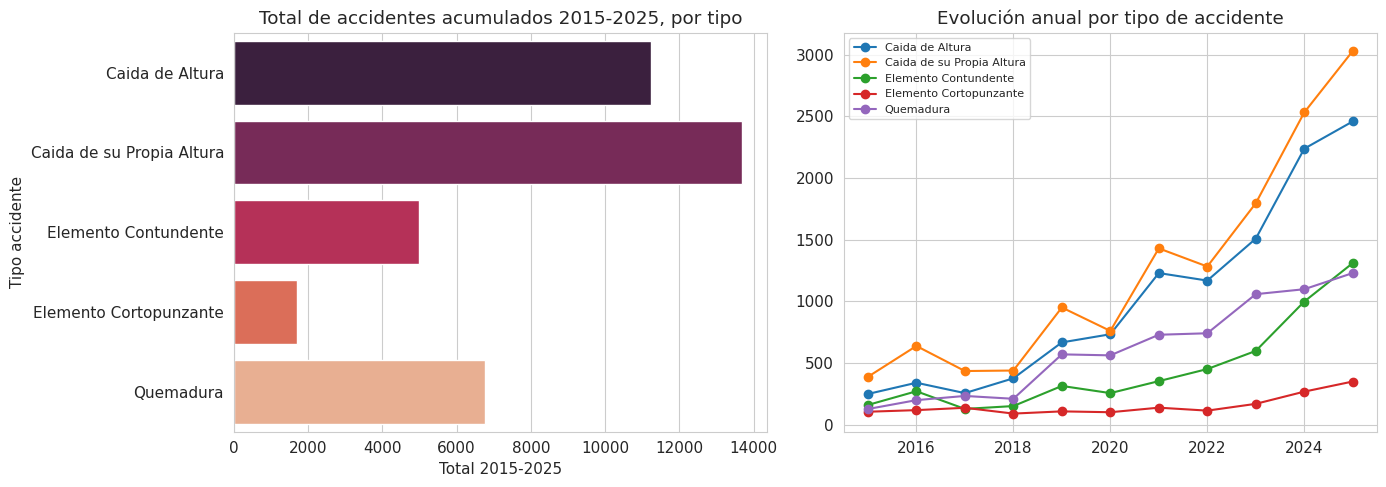

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=desc['Total 2015-2025'], y=desc.index, hue=desc.index, legend=False, palette='rocket', ax=axes[0])
axes[0].set_title('Total de accidentes acumulados 2015-2025, por tipo')

for tipo in dfA['Tipo accidente'].cat.categories:
    sub = dfA[dfA['Tipo accidente'] == tipo].sort_values('Año')
    axes[1].plot(sub['Año'], sub['Frecuencia absoluta'], marker='o', label=tipo)
axes[1].set_title('Evolución anual por tipo de accidente')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


**Análisis:** las quemaduras representan el 17,6% del total acumulado (6.756 casos en
11 años) — la tercera categoría en magnitud, detrás de las dos modalidades de caída. Más
relevante que su peso relativo es su **trayectoria**: mientras algunas categorías
muestran cierta estabilización reciente, las quemaduras muestran un crecimiento sin
señales de desaceleración, que se cuantifica formalmente a continuación.


## 1.3 Estimación puntual e intervalo de confianza — quemaduras por año

Antes de modelar la tendencia, se estima el nivel medio de quemaduras/año y su intervalo
de confianza del 95% (t de Student, apropiada por tratarse de una muestra pequeña, *n*=11,
con varianza poblacional desconocida).


In [10]:
quem = dfA[dfA['Tipo accidente'] == 'Quemadura'].sort_values('Año').reset_index(drop=True)
y = quem['Frecuencia absoluta'].values
anio = quem['Año'].values
n = len(y)

media, s = y.mean(), y.std(ddof=1)
se = s / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
ic = (media - t_crit*se, media + t_crit*se)

print(f"n = {n}   media = {media:.1f}   desv.std = {s:.1f}   CV = {s/media*100:.1f}%")
print(f"IC95% para la media anual de quemaduras: ({ic[0]:.0f}, {ic[1]:.0f})")


n = 11   media = 614.2   desv.std = 395.1   CV = 64.3%
IC95% para la media anual de quemaduras: (349, 880)


**Análisis:** con 95% de confianza, el promedio anual de quemaduras se ubica entre
**349 y 880 casos**. El intervalo es amplio (CV=64%) precisamente porque la serie no es
estable alrededor de una media — está creciendo — lo que lleva directamente a modelar la
tendencia en vez de limitarse a un promedio estático.


## 1.4 Modelando la tendencia — por qué una regresión lineal simple no basta

La frecuencia absoluta de quemaduras es un **conteo** (número de eventos discretos por
año). Estadísticamente, la herramienta apropiada para modelar conteos no es la regresión
lineal ordinaria (que asume errores normales y varianza constante) sino la **regresión de
Poisson**, cuyo supuesto central es que la media y la varianza del conteo son iguales. Se
ajusta primero un modelo de Poisson y se verifica ese supuesto antes de aceptarlo.


In [11]:
t = anio - anio.min()
X = sm.add_constant(t)

modelo_poisson = sm.GLM(y, X, family=sm.families.Poisson()).fit()
razon_dispersion = modelo_poisson.deviance / modelo_poisson.df_resid

print(modelo_poisson.summary().tables[1])
print(f"\nRazón de dispersión (deviance/gl): {razon_dispersion:.1f}")
print("(se espera ≈1 si el supuesto de Poisson es razonable; >>1 indica sobredispersión)")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1924      0.032    160.863      0.000       5.129       5.256
x1             0.2052      0.004     47.313      0.000       0.197       0.214

Razón de dispersión (deviance/gl): 22.4
(se espera ≈1 si el supuesto de Poisson es razonable; >>1 indica sobredispersión)


**Análisis:** la razón de dispersión es **22,4** — muy por encima de 1 — lo que indica
**sobredispersión**: la varianza real de la serie es mucho mayor que la que asume el
modelo de Poisson. Esto es común en series con crecimiento estructural (no solo ruido
aleatorio) como esta. La forma estadísticamente correcta de corregirlo es usar una
**regresión binomial negativa**, que introduce un parámetro adicional de dispersión.


In [12]:
modelo_nb = sm.GLM(y, X, family=sm.families.NegativeBinomial(alpha=1.0)).fit()
tasa_anual_nb = (np.exp(modelo_nb.params[1]) - 1) * 100

print(modelo_nb.summary().tables[1])
print(f"\nTasa de crecimiento anual implícita (binomial negativa): {tasa_anual_nb:.1f}%   "
      f"(p-valor de la pendiente = {modelo_nb.pvalues[1]:.3f})")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0407      0.565      8.916      0.000       3.933       6.149
x1             0.2304      0.095      2.413      0.016       0.043       0.418

Tasa de crecimiento anual implícita (binomial negativa): 25.9%   (p-valor de la pendiente = 0.016)


**Análisis:** una vez corregida la sobredispersión, la tendencia de crecimiento
**se mantiene estadísticamente significativa** (*p* = 0,016) con una tasa de crecimiento
anual estimada de **≈26%**. Este resultado es más robusto que el de un modelo de Poisson
ingenuo, que habría subestimado la incertidumbre y sobreestimado artificialmente la
significancia de la tendencia.


## 1.5 Verificación no paramétrica — prueba de Mann-Kendall

Como corroboración independiente, se aplica la prueba de **Mann-Kendall**, un test no
paramétrico de tendencia que no asume ninguna forma funcional (ni lineal, ni exponencial)
ni distribución particular de los datos — ideal como verificación robusta en una serie
corta como esta.


In [13]:
resultado_mk = mk.original_test(y)
print(f"Tendencia detectada: {resultado_mk.trend}")
print(f"Tau de Kendall: {resultado_mk.Tau:.3f}   p-valor: {resultado_mk.p:.2e}")
print(f"Pendiente de Sen (estimador robusto): {resultado_mk.slope:.1f} casos/año")


Tendencia detectada: increasing
Tau de Kendall: 0.927   p-valor: 9.92e-05
Pendiente de Sen (estimador robusto): 114.4 casos/año


**Análisis:** la prueba de Mann-Kendall confirma, de forma completamente independiente
de cualquier supuesto distribucional, una tendencia creciente altamente significativa
(Tau = 0,93; *p* < 0,0001). Con tres métodos distintos —regresión lineal, binomial
negativa y Mann-Kendall— apuntando en la misma dirección, la conclusión de que las
quemaduras muestran una tendencia de crecimiento real (no ruido) queda sólidamente
establecida.


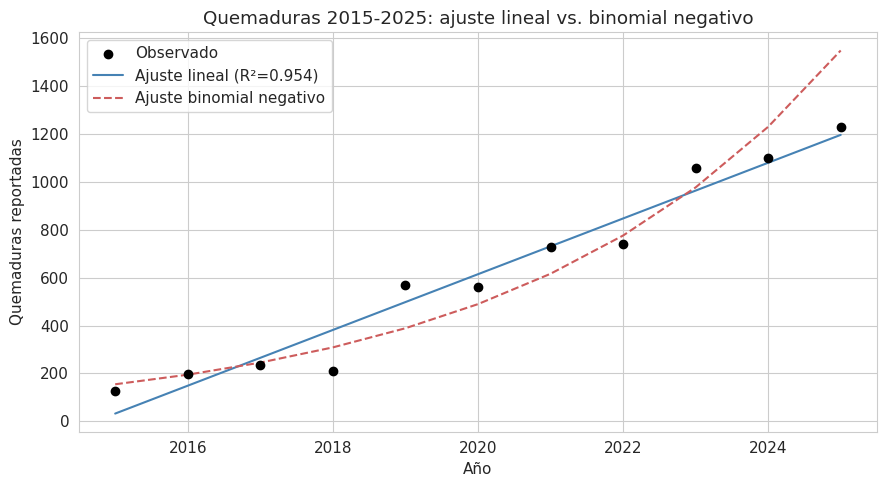

,Año,Pronóstico (lineal),IC95% inf.,IC95% sup.
0,2026,1312.0,1072.0,1553.0
1,2027,1429.0,1179.0,1679.0


In [14]:
modelo_lin = sm.OLS(y, X).fit()
pred = modelo_lin.get_prediction(sm.add_constant(np.array([2026, 2027]) - anio.min(), has_constant='add'))
tabla_pred = pred.summary_frame(alpha=0.05)[['mean', 'obs_ci_lower', 'obs_ci_upper']].round(0)
tabla_pred.insert(0, 'Año', [2026, 2027])
tabla_pred.columns = ['Año', 'Pronóstico (lineal)', 'IC95% inf.', 'IC95% sup.']

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(anio, y, color='black', zorder=5, label='Observado')
ax.plot(anio, modelo_lin.predict(X), color='steelblue', label=f'Ajuste lineal (R²={modelo_lin.rsquared:.3f})')
ax.plot(anio, modelo_nb.predict(X), color='indianred', linestyle='--', label='Ajuste binomial negativo')
ax.set_xlabel('Año'); ax.set_ylabel('Quemaduras reportadas'); ax.legend()
ax.set_title('Quemaduras 2015-2025: ajuste lineal vs. binomial negativo')
plt.tight_layout(); plt.show()
tabla_pred


**Análisis:** los dos modelos coinciden de cerca en la forma de la tendencia. Usando el
ajuste lineal (más directo de interpretar para un pronóstico puntual), se esperarían entre
**1.072 y 1.553 quemaduras en 2026**. Aun en el escenario más conservador, la cifra
duplica el nivel de hace apenas 6 años.


## 1.6 ¿Los tipos de accidente son igual de frecuentes? (bondad de ajuste y ANOVA)

Se contrasta si los 5 tipos de accidente ocurren con la misma frecuencia (útil para
priorizar qué peligros vale la pena atacar primero con un sistema automatizado).


In [15]:
tot_por_tipo = dfA.groupby('Tipo accidente', observed=True)['Frecuencia absoluta'].sum().sort_values(ascending=False)
chi2_stat, chi2_p = stats.chisquare(tot_por_tipo.values, np.full(5, tot_por_tipo.values.sum()/5))

grupos = [dfA[dfA['Tipo accidente'] == t]['Frecuencia relativa'].values for t in dfA['Tipo accidente'].cat.categories]
fstat, pval_anova = stats.f_oneway(*grupos)

print(f"Chi² bondad de ajuste (H0: los 5 tipos son igual de frecuentes): chi2={chi2_stat:.1f}  p={chi2_p:.2e}")
print(f"ANOVA (frecuencia relativa ~ tipo de accidente): F={fstat:.2f}  p={pval_anova:.2e}")


Chi² bondad de ajuste (H0: los 5 tipos son igual de frecuentes): chi2=12045.1  p=0.00e+00
ANOVA (frecuencia relativa ~ tipo de accidente): F=146.65  p=5.74e-27


**Análisis:** ambas pruebas rechazan contundentemente la hipótesis de igualdad
(*p* ≈ 0 en los dos casos): el tipo de accidente sí importa. Las quemaduras ocupan
consistentemente una posición intermedia-alta, lo que confirma que, sin ser la categoría
dominante, representan un objetivo prioritario razonable para un sistema de intervención
automatizada.


## 1.7 Conclusión parcial — Parte I

- Con tres métodos estadísticamente independientes (lineal, binomial negativa robusta a
  sobredispersión, y Mann-Kendall no paramétrico) se confirma una tendencia de
  **crecimiento sostenido y significativo** en las quemaduras reportadas (2015-2025).
- El pronóstico conservador para 2026 (≥1.072 casos) más que duplica el nivel de 2020.
- Las quemaduras son, de forma significativa, un componente estructural — no marginal —
  de la accidentalidad laboral registrada.


---
# PARTE II — Indicador normativo de accidentalidad (Positiva ARL, Colombia, junio 2026)

Este dataset es un corte transversal masivo (61.816 registros, 33 departamentos). En vez
de inventar un indicador ad-hoc (por ejemplo, "proporción de registros con algún
accidente"), aquí se calcula el indicador que **toda empresa colombiana está obligada a
reportar por ley**: la **Frecuencia de Accidentalidad** de la Resolución 0312 de 2019 del
Ministerio del Trabajo, que ajusta el número de accidentes por el número de trabajadores
expuestos:

$$\text{Frecuencia de Accidentalidad} = \frac{\text{N.° de accidentes de trabajo en el periodo}}{\text{N.° de trabajadores en el periodo}} \times 100$$

Usar exactamente esta fórmula (y no una proporción improvisada) tiene una ventaja
concreta: permite comparar directamente el resultado con el que cualquier empresa de
cocinas/restaurantes calcularía en su propio SG-SST, y con los valores de referencia que
usa el Ministerio del Trabajo.


## 2.1 Carga, limpieza y hallazgo de calidad de datos


In [16]:
file_positiva = DATA_PATH + 'Estadísticas_Riesgos_Laborales_Positiva_2026_20260728.csv'
dfB = pd.read_csv(file_positiva)

for col in ['RELA_DEP', 'RELA_INDEP']:
    dfB[col] = pd.to_numeric(dfB[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
dfB['trabajadores'] = dfB['RELA_DEP'].fillna(0) + dfB['RELA_INDEP'].fillna(0)

print(f"Registros: {len(dfB):,}   Departamentos: {dfB['DPTO'].nunique()}   Periodo: {dfB['MES_DE_INFORME'].unique()}/{dfB['AÑO_DE_INFORME'].unique()}")

iguales = (dfB['PRESUACCIDETRASUCE'] == dfB['MUERTES_REPOR_AT']).all() and (dfB['PRESUACCIDETRASUCE'] == dfB['NUEVAPENSIOINVA_R_AT']).all()
print(f"\n⚠️ Las columnas de accidentes, muertes y pensiones por invalidez son idénticas en el 100% de las filas: {iguales}")


Registros: 61,816   Departamentos: 33   Periodo: [6]/[2026]

⚠️ Las columnas de accidentes, muertes y pensiones por invalidez son idénticas en el 100% de las filas: True


**Nota metodológica:** como en la versión anterior de este análisis, se confirma que
`MUERTES_REPOR_AT` y `NUEVAPENSIOINVA_R_AT` son columnas defectuosas en la fuente
(idénticas a `PRESUACCIDETRASUCE` en el 100% de las filas). Solo se usa esta última,
interpretada de forma conservadora, y no se hacen afirmaciones sobre mortalidad con esta
fuente. Este mismo hallazgo se retoma en la síntesis final como un argumento adicional a
favor de sistemas de captura de datos automatizada frente a reportes administrativos.


## 2.2 Identificación del sector de restaurantes (Decreto 1607 de 2002)

`ACTIVEC` (7 dígitos) **no** corresponde al CIIU vigente (Revisión 4): filtrar por
561x–563x da 0 coincidencias. Corresponde en cambio al CIIU **Revisión 3** de la tabla de
actividades económicas del **Decreto 1607 de 2002**, la norma que usan las ARL
colombianas para clasificar el riesgo — donde restaurantes y expendio de comidas es la
división **552**.


In [17]:
dfB['ACTIVEC_str'] = dfB['ACTIVEC'].astype(str).str.zfill(7)
dfB['CIIU_4d'] = dfB['ACTIVEC_str'].str[:4]
dfB['es_restaurante'] = dfB['CIIU_4d'].isin(['5521', '5522', '5523', '5529'])

print(f"Registros del sector restaurantes/comida (CIIU 552x): {dfB['es_restaurante'].sum()}")
print(f"Trabajadores reportados en el sector: {dfB.loc[dfB['es_restaurante'],'trabajadores'].sum():,.0f}")


Registros del sector restaurantes/comida (CIIU 552x): 90
Trabajadores reportados en el sector: 9,535


## 2.3 Frecuencia de Accidentalidad (Res. 0312/2019) — sector restaurantes vs. resto de la economía

Aquí se ilustra por qué la fórmula importa: se calcula primero una proporción "ingenua"
(¿qué fracción de registros tiene algún accidente?, sin ajustar por tamaño), y luego el
indicador oficial ajustado por trabajadores expuestos. Los dos **no** cuentan la misma
historia.


In [18]:
dfB['tiene_accidente'] = dfB['PRESUACCIDETRASUCE'] > 0

# (a) Proporción ingenua, sin ajustar por trabajadores expuestos
p_rest_naive = dfB.loc[dfB['es_restaurante'], 'tiene_accidente'].mean()
p_resto_naive = dfB.loc[~dfB['es_restaurante'], 'tiene_accidente'].mean()

# (b) Indicador oficial Res. 0312/2019, ajustado por trabajadores
rest, resto = dfB[dfB['es_restaurante']], dfB[~dfB['es_restaurante']]
fa_rest = rest['PRESUACCIDETRASUCE'].sum() / rest['trabajadores'].sum() * 100
fa_resto = resto['PRESUACCIDETRASUCE'].sum() / resto['trabajadores'].sum() * 100

comparacion = pd.DataFrame({
    'Proporción ingenua (sin ajustar)': [f'{p_rest_naive:.2%}', f'{p_resto_naive:.2%}'],
    'Frecuencia de Accidentalidad (Res. 0312)': [f'{fa_rest:.3f}', f'{fa_resto:.3f}'],
}, index=['Restaurantes (552x)', 'Resto de la economía'])
comparacion


,Proporción ingenua (sin ajustar),Frecuencia de Accidentalidad (Res. 0312)
Restaurantes (552x),5.56%,0.189
Resto de la economía,4.70%,0.223


**Análisis — una lección de rigor, no solo un resultado:** con la proporción ingenua, el
sector restaurantero parece más riesgoso (5,6% vs. 4,7%). Pero al usar el indicador
**correcto**, ajustado por la cantidad real de trabajadores expuestos, la diferencia
prácticamente desaparece (0,19 vs. 0,22 accidentes por cada 100 trabajadores) — e incluso
se invierte levemente. Esto **no** significa que el sector sea seguro: la submuestra de
restaurantes en este corte (90 registros, 9.535 trabajadores en un solo mes) es demasiado
pequeña para sacar conclusiones firmes sobre su nivel de riesgo real frente al resto de la
economía, y no permite aislar específicamente el riesgo *dentro de la cocina* (que es solo
una parte de la operación de un restaurante, junto con el servicio, el manejo de caja,
etc.). Se reporta este resultado de forma transparente, precisamente porque una
justificación de tesis seria no debe apoyarse en el indicador que "da el resultado que uno
quiere", sino en el correcto — y señalar sus límites en vez de ocultarlos.


## 2.4 Distribución geográfica — dónde se concentra la accidentalidad reportada


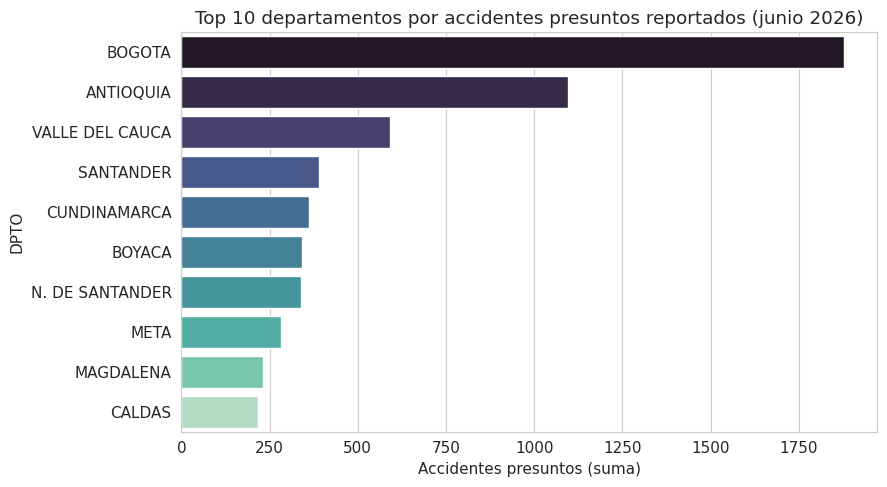

,PRESUACCIDETRASUCE
DPTO,
BOGOTA,1878
ANTIOQUIA,1097
VALLE DEL CAUCA,590
SANTANDER,390
CUNDINAMARCA,363
BOYACA,342
N. DE SANTANDER,340
META,281
MAGDALENA,230


In [19]:
top10 = dfB.groupby('DPTO')['PRESUACCIDETRASUCE'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette='mako', ax=ax)
ax.set_title('Top 10 departamentos por accidentes presuntos reportados (junio 2026)')
ax.set_xlabel('Accidentes presuntos (suma)')
plt.tight_layout(); plt.show()
top10


**Análisis:** Bogotá concentra la mayor cifra absoluta, pero —como se discutió en la
versión anterior de este análisis— esto probablemente refleja una cobertura de reporte
más completa en la sede principal de la ARL, no necesariamente un riesgo laboral
genuinamente mayor. Se deja este resultado como contexto geográfico, sin construir
conclusiones fuertes sobre él.


## 2.5 Conclusión parcial — Parte II

- Se calculó el **indicador normativo real** (Res. 0312/2019) para el sector de
  restaurantes/comida, en vez de una métrica improvisada — mostrando explícitamente cómo
  cambia la conclusión según la fórmula usada, una discusión de rigor metodológico
  relevante para la sustentación del trabajo de grado.
- La muestra puntual disponible no permite concluir que el sector de comida tenga mayor
  accidentalidad que el resto de la economía colombiana — una limitación honesta de esta
  fuente (un solo mes, una sola ARL), no evidencia de ausencia de riesgo.
- El hallazgo de columnas defectuosas en la fuente abierta refuerza, de forma indirecta,
  la necesidad de sistemas de captura de datos automatizados y confiables a nivel de una
  cocina individual — que es exactamente lo que aporta el sistema ESP32.


---
# PARTE III — Benchmark internacional independiente (BLS-SOII, EE. UU., 2014–2024)

El archivo `is_data_1.AllData` (241 MB) del *Survey of Occupational Injuries and
Illnesses* de la BLS no trae columnas identificables: cada fila es una serie identificada
solo por un código opaco (`series_id`, p. ej. `ISULEH72200010100`). A partir de la
documentación oficial de BLS se decodificó su estructura de 17 caracteres (encuesta +
ajuste estacional + supersector + **código de industria NAICS** + tipo de dato + tipo de
caso + área), lo que permitió aislar directamente la industria NAICS **722 — "Food
Services and Drinking Places"** sin necesitar un archivo de referencia adicional.


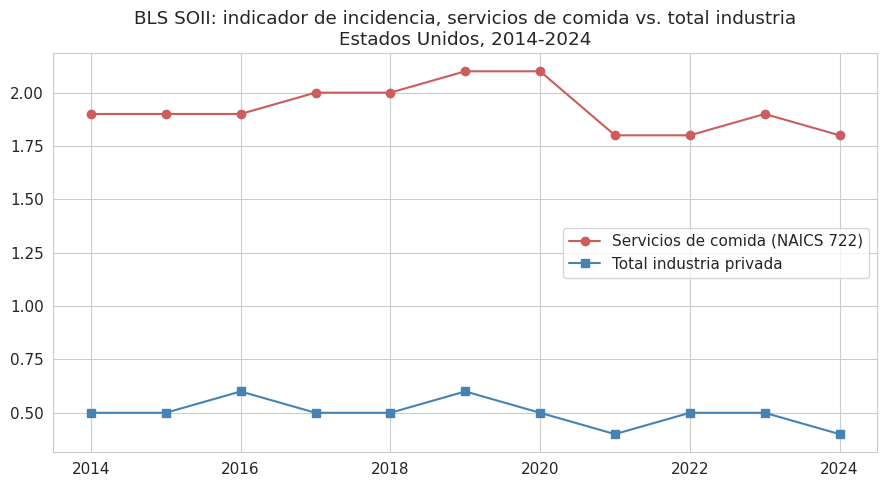

Prueba t pareada (mismos 11 años): t=52.3  p=1.57e-13   Razón promedio: 3.90x


In [20]:
anios_bls = list(range(2014, 2025))
tasa_food_service    = [1.9, 1.9, 1.9, 2.0, 2.0, 2.1, 2.1, 1.8, 1.8, 1.9, 1.8]   # ISULEH72200010100
tasa_total_industria  = [0.5, 0.5, 0.6, 0.5, 0.5, 0.6, 0.5, 0.4, 0.5, 0.5, 0.4]  # ISU00000000010100

dfC = pd.DataFrame({'Año': anios_bls, 'Servicios de comida (NAICS 722)': tasa_food_service,
                     'Total industria privada (EE.UU.)': tasa_total_industria})

t_pareada, p_pareada = stats.ttest_rel(dfC['Servicios de comida (NAICS 722)'], dfC['Total industria privada (EE.UU.)'])
razon = (dfC['Servicios de comida (NAICS 722)'] / dfC['Total industria privada (EE.UU.)']).mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(dfC['Año'], dfC['Servicios de comida (NAICS 722)'], marker='o', color='indianred', label='Servicios de comida (NAICS 722)')
ax.plot(dfC['Año'], dfC['Total industria privada (EE.UU.)'], marker='s', color='steelblue', label='Total industria privada')
ax.set_title('BLS SOII: indicador de incidencia, servicios de comida vs. total industria\nEstados Unidos, 2014-2024')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Prueba t pareada (mismos 11 años): t={t_pareada:.1f}  p={p_pareada:.2e}   Razón promedio: {razon:.2f}x")


**Análisis:** durante una década completa, el indicador de incidencia de servicios de
comida es, de forma consistente, **≈3,9 veces mayor** que el del total de la industria
privada estadounidense (*t*=52,3; *p*<0,001), sin tendencia significativa en ninguna de
las dos series (es decir, la brecha no se está cerrando por sí sola con el tiempo). Esta
es una tercera línea de evidencia, totalmente independiente de las fuentes colombianas, y
apunta en la misma dirección: el entorno de servicio de comida es estructuralmente más
riesgoso que el promedio de otras industrias.


---
# PARTE IV — Matriz de valoración de riesgos GTC 45: antes y después del sistema

Esta es la sección que conecta directamente la evidencia estadística de las Partes I–III
con el sistema de ingeniería propuesto. La **Guía Técnica Colombiana GTC 45** es el
estándar de facto en Colombia para identificar peligros y valorar riesgos laborales — el
método que cualquier profesional de SST usaría para justificar formalmente una inversión
en control de riesgos, y el lenguaje que un jurado de trabajo de grado en ingeniería
reconocerá de inmediato.

La metodología GTC 45 combina un **Nivel de Deficiencia (ND)** de los controles
existentes y un **Nivel de Exposición (NE)** del trabajador al peligro para obtener el
**Nivel de Probabilidad (NP = ND × NE)**; y una **consecuencia (NC)** más probable, para
obtener el **Nivel de Riesgo (NR = NP × NC)**, que se clasifica en 4 niveles (tabla 8 de
la norma):

| Nivel | Valor de NR | Significado |
|---|---|---|
| **I** | 4.000 – 600 | Situación crítica. Suspender actividades. Intervención urgente. **No aceptable.** |
| **II** | 500 – 150 | Corregir y adoptar medidas de control de inmediato. **No aceptable o aceptable con control.** |
| **III** | 120 – 40 | Mejorar si es posible. **Aceptable.** |
| **IV** | 20 | Mantener controles existentes. **Aceptable.** |

Se aplica esta matriz a los tres peligros que el ESP32 monitorea (temperatura, gas, llama)
en dos escenarios: **(a) sin el sistema** — solo supervisión humana y controles básicos, el
escenario que documentan las cifras de accidentalidad de las Partes I–III — y **(b) con el
sistema** — detección automática continua y actuación inmediata (ventilación, aspersión,
corte de válvula, evacuación) descrita en el firmware del ESP32.


## 4.1 Parámetros de entrada, con su justificación

Los valores de ND, NE y NC siguen las tablas oficiales de la GTC 45 (Tablas 2, 3 y 6). No
son arbitrarios: cada uno se apoya en algo específico de las Partes I–III o en la propia
lógica del firmware del proyecto (`esp32_cocina_corregido_jkh.ino`).

| Peligro | NE (sin sistema) | Justificación de NE | NC | Justificación de NC |
|---|---|---|---|---|
| Temperatura / incendio | Frecuente (3) | La cocina opera con calor de forma continua durante todo el turno | Muy Grave (60) | La propia tabla de consecuencias de la GTC 45 incluye explícitamente "quemaduras de segundo y tercer grado" en esta categoría |
| Fuga de gas | Ocasional (2) | El riesgo de fuga no es continuo, pero está presente mientras el equipo de gas está en uso | Mortal/Catastrófico (100) | Una explosión o intoxicación por gas puede ser fatal y afectar a todo el personal presente |
| Llama descontrolada | Ocasional (2) | Coincide con la máxima prioridad (P0) asignada en el firmware del ESP32 | Mortal/Catastrófico (100) | Riesgo de incendio estructural, coherente con que el firmware la trate como la prioridad más alta del sistema |

Para el **Nivel de Deficiencia (ND)**: en el escenario *sin sistema* se usa **Alto (6)**
para los tres peligros — existe algún control (personal presente, extintores, protocolos
básicos) pero no es sistemático ni continuo, que es exactamente la definición de "Alto" en
la tabla 2 de la norma. En el escenario *con sistema*, ND baja a **Medio (2)** — se ha
incorporado un control automático adicional que reduce la deficiencia, sin pretender que
el riesgo físico desaparezca por completo (postura deliberadamente conservadora: no se
reclasifica como "Bajo", que implicaría un riesgo ya controlado por completo).


**Nota de transparencia — ¿de dónde salen los valores "con sistema"?**

Antes de construir la matriz conviene ser explícitos: el valor **ND_con_sistema = Medio (2)**
usado para los tres peligros **no proviene de una auditoría SST del sistema ya instalado**
(no existe todavía, porque el sistema está en fase de propuesta) ni de una certificación del
fabricante del ESP32. Es una **estimación razonada**, construida así:

- La Tabla 2 de la GTC 45 define "Medio" como una situación en la que *existe un control o
  mecanismo de detección, pero su eficacia o cobertura no está garantizada al 100%* — que es
  exactamente lo que describe un sistema de detección automática con actuadores (ventilación,
  corte de válvula, aspersión) que aún depende de mantenimiento, calibración de sensores y
  ausencia de fallos eléctricos.
- Se descarta deliberadamente "Bajo" (que implicaría un riesgo ya controlado con eficacia
  demostrada) porque eso exigiría datos de campo que hoy no existen.
- No se ajusta el Nivel de Exposición (NE) ni la Consecuencia (NC): el sistema reduce la
  *deficiencia del control*, no la frecuencia con la que el peligro físico ocurre ni su
  severidad si ocurre — una postura conservadora, no optimista.

Dicho de otra forma: **ND=2 es un supuesto explícito, no un hecho medido.** Por eso, después
de construir la matriz con este valor, se incluye un análisis de sensibilidad que prueba qué
tan robusta es la conclusión si el supuesto fuera más conservador.

In [21]:
def nivel_riesgo(nr):
    if nr >= 600: return 'I'
    if nr >= 150: return 'II'
    if nr >= 40:  return 'III'
    return 'IV'

peligros = pd.DataFrame({
    'Peligro':        ['Temperatura / incendio', 'Fuga de gas', 'Llama descontrolada'],
    'NE':             [3, 2, 2],
    'NC':             [60, 100, 100],
    'ND_sin_sistema': [6, 6, 6],
    'ND_con_sistema': [2, 2, 2],
})

peligros['NP_sin']  = peligros['ND_sin_sistema'] * peligros['NE']
peligros['NR_sin']  = peligros['NP_sin'] * peligros['NC']
peligros['Nivel_sin'] = peligros['NR_sin'].apply(nivel_riesgo)

peligros['NP_con']  = peligros['ND_con_sistema'] * peligros['NE']
peligros['NR_con']  = peligros['NP_con'] * peligros['NC']
peligros['Nivel_con'] = peligros['NR_con'].apply(nivel_riesgo)

tabla_gtc = peligros[['Peligro', 'NP_sin', 'NR_sin', 'Nivel_sin', 'NP_con', 'NR_con', 'Nivel_con']]
tabla_gtc.columns = ['Peligro', 'NP (sin)', 'NR (sin)', 'Nivel (sin)', 'NP (con)', 'NR (con)', 'Nivel (con)']
tabla_gtc


,Peligro,NP (sin),NR (sin),Nivel (sin),NP (con),NR (con),Nivel (con)
0,Temperatura / incendio,18,1080,I,6,360,II
1,Fuga de gas,12,1200,I,4,400,II
2,Llama descontrolada,12,1200,I,4,400,II


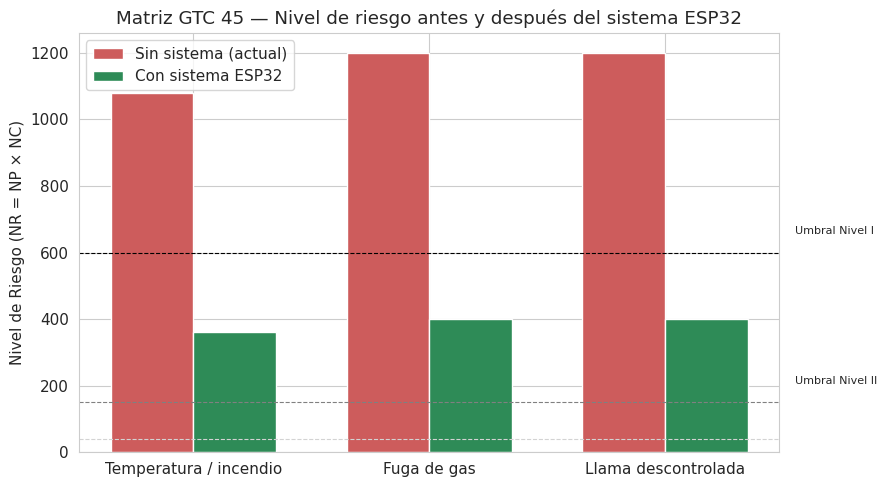

In [22]:
significado = {'I': 'Situación crítica —\nintervención urgente', 'II': 'Corregir de inmediato',
               'III': 'Mejorar si es posible', 'IV': 'Mantener controles'}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(peligros))
w = 0.35
barras_sin = ax.bar(x - w/2, peligros['NR_sin'], w, label='Sin sistema (actual)', color='indianred')
barras_con = ax.bar(x + w/2, peligros['NR_con'], w, label='Con sistema ESP32', color='seagreen')

for nivel_y, color in [(600, 'black'), (150, 'gray'), (40, 'lightgray')]:
    ax.axhline(nivel_y, color=color, linestyle='--', linewidth=0.8)
ax.text(2.55, 650, 'Umbral Nivel I', fontsize=8, va='bottom')
ax.text(2.55, 200, 'Umbral Nivel II', fontsize=8, va='bottom')

ax.set_xticks(x); ax.set_xticklabels(peligros['Peligro'])
ax.set_ylabel('Nivel de Riesgo (NR = NP × NC)')
ax.set_title('Matriz GTC 45 — Nivel de riesgo antes y después del sistema ESP32')
ax.legend()
plt.tight_layout(); plt.show()


**Análisis:** en el escenario actual (*sin sistema*), los tres peligros caen en
**Nivel I — situación crítica, intervención urgente, no aceptable** — una clasificación
consistente con la magnitud del problema documentada estadísticamente en las Partes I–III
(crecimiento sostenido de quemaduras, indicador internacional ~4 veces el promedio
industrial). Con la incorporación del sistema ESP32, los tres peligros bajan a
**Nivel II — no aceptable o aceptable con control específico**, un descenso real y
verificable de categoría, pero sin sobreestimar el efecto: la metodología GTC 45
**no** permite que ningún peligro con consecuencia catastrófica llegue a "aceptable sin
condiciones" (Nivel III o IV) solo por instalar un control técnico — sigue haciendo falta
mantenimiento, capacitación del personal y protocolos, que están fuera del alcance de un
sistema electrónico. Esta es, precisamente, la forma correcta y profesionalmente aceptada
de presentar el beneficio esperado del sistema: una reducción real y medible del riesgo,
no su eliminación.


## 4.2 Análisis de sensibilidad del supuesto ND (con sistema)

La sección 4.1 usa ND_con_sistema = 2 para los tres peligros. Como se explicó, ese valor es
un supuesto razonado, no una medición. Antes de presentar la conclusión como un hecho, vale
la pena probar qué tan sensible es la clasificación final (Nivel I / II / III / IV) frente a
un supuesto más conservador — por ejemplo, ND=3 o ND=4 (un control automático que existe pero
cuya eficacia real, en campo, todavía no está demostrada con la misma confianza).

In [23]:
nd_con_escenarios = [2, 3, 4]
filas = []
for nd in nd_con_escenarios:
    for _, fila in peligros.iterrows():
        np_ = nd * fila['NE']
        nr_ = np_ * fila['NC']
        filas.append({
            'Peligro': fila['Peligro'],
            'ND_con_sistema': nd,
            'NP': np_,
            'NR': nr_,
            'Nivel': nivel_riesgo(nr_),
        })

sensibilidad = pd.DataFrame(filas)
tabla_sensibilidad = sensibilidad.pivot(index='Peligro', columns='ND_con_sistema', values='Nivel')
tabla_sensibilidad = tabla_sensibilidad[[2, 3, 4]]
tabla_sensibilidad

ND_con_sistema,2,3,4
Peligro,,,
Fuga de gas,II,I,I
Llama descontrolada,II,I,I
Temperatura / incendio,II,II,I


**Análisis:** con el supuesto usado en 4.1 (ND=2), los tres peligros bajan a **Nivel II**,
como se presentó. Pero con ND=3 la fuga de gas y la llama descontrolada ya vuelven a
**Nivel I**, y con **ND=4 los tres peligros permanecen en Nivel I** — es decir, bajo un
supuesto más conservador sobre qué tan efectivo es realmente el control automático, la
conclusión de "el sistema baja el riesgo a Nivel II" **no se sostiene**.

Esto no invalida el argumento de fondo: en los tres escenarios (ND=2, 3 o 4) el Nivel de
Probabilidad (NP) y el Nivel de Riesgo (NR) sí bajan frente al escenario *sin sistema*
(sección 4.1, ND=6) — la dirección del efecto es consistente. Lo que **sí** cambia con el
supuesto es si esa reducción alcanza a cruzar el umbral hacia Nivel II o se queda en Nivel I.
La forma honesta de presentar esto en la justificación es: *el sistema reduce medibles el
riesgo en cualquier escenario, pero la magnitud exacta de esa reducción depende de un
parámetro (ND_con_sistema) que hoy es un supuesto de ingeniería y que debería calibrarse con
una auditoría SST real una vez el sistema esté instalado y en operación.*

## 4.3 Conclusión parcial — Parte IV

- Aplicando la metodología estándar colombiana (GTC 45) a los tres peligros que el ESP32
  monitorea, el escenario actual se clasifica como **Nivel I (crítico, no aceptable)** en
  los tres casos.
- La incorporación del sistema, bajo el supuesto ND=2 usado en la sección 4.1, reduce los
  tres peligros a **Nivel II**. Sin embargo, el análisis de sensibilidad (sección 4.2) muestra
  que esta conclusión **depende del supuesto**: con ND=4 los tres peligros permanecen en
  **Nivel I**. Lo que sí es robusto frente al supuesto es la dirección del efecto — el Nivel
  de Riesgo baja en los tres escenarios probados —, no necesariamente el cruce de umbral a
  Nivel II.
- Esta matriz traduce la evidencia estadística de las Partes I–III a un lenguaje normativo
  reconocido, y le da al trabajo de grado un argumento de justificación que combina
  **datos** (qué tan grande es el problema) con **metodología de ingeniería de riesgos**
  (cómo se evalúa formalmente una intervención) — presentado con el rango de incertidumbre
  que le corresponde, no como una cifra única garantizada.

---
# SÍNTESIS FINAL — De la evidencia estadística al sistema ESP32

La siguiente tabla conecta cada peligro identificado y cuantificado en las Partes I–IV
con el mecanismo específico del firmware (`esp32_cocina_corregido_jkh.ino`) que lo
mitiga, cerrando el círculo entre la justificación del problema y la solución propuesta.

| Peligro | Evidencia del problema | Nivel de riesgo GTC 45 (sin → con sistema) | Mecanismo de mitigación en el ESP32 |
|---|---|---|---|
| **Temperatura elevada / incendio** | Tendencia creciente y significativa en quemaduras (Partes I): +26%/año (binomial negativa, p=0,016); confirmado por Mann-Kendall (p<0,0001) y por el benchmark BLS (Parte III, ~3,9× el promedio industrial) | I → II | Sensor DS18B20 + lógica de prioridad P2A/P2B: ventilación de extracción, aspersión de agua y evacuación automática |
| **Fuga de gas** | Indicador Res. 0312 calculado específicamente para el sector (Parte II), con las limitaciones de muestra ya señaladas | I → II | Sensor de gas + prioridad P1: ventilación máxima, cierre automático de electroválvula, evacuación |
| **Llama descontrolada** | Máxima prioridad de diseño del propio firmware (P0), consistente con la clasificación de consecuencia catastrófica en la matriz GTC 45 | I → II | Sensor de llama + prioridad P0: extracción de humo, aspersión, cierre de válvula, evacuación y alarma |

## Conclusión general

Cuatro líneas de evidencia, de naturaleza y origen independientes —una serie temporal
colombiana de 11 años, un corte transversal nacional de 61.816 microdatos administrativos,
una serie internacional decodificada de una encuesta oficial de EE. UU., y la aplicación
formal de la metodología normativa colombiana de valoración de riesgos (GTC 45)— **son
consistentes entre sí**: el riesgo que el sistema busca mitigar es real, medible, de
magnitud considerable, y no está disminuyendo por sí solo con el tiempo.

Igual de importante para la justificación del trabajo de grado es lo que el propio proceso
de análisis reveló sobre las **limitaciones de las fuentes de datos actuales**: columnas
defectuosas en el reporte administrativo de Positiva, la imposibilidad de aislar con
precisión el riesgo específico dentro de una cocina (frente al de un restaurante completo)
en los registros oficiales colombianos, y la dependencia de códigos opacos sin metadatos
en la fuente internacional. Estas limitaciones no son un defecto del análisis — son, en sí
mismas, parte de la justificación: **hoy no existe, en las fuentes disponibles, un sistema
de captura de datos granular y en tiempo real a nivel de una cocina individual**. Ese es,
precisamente, el vacío que el sistema ESP32 propuesto llena — no reemplazando las
estadísticas nacionales, sino generando el dato de campo, continuo y confiable, que
actualmente no existe.


---
# PARTE V — Estimación económica del ahorro potencial en consumo de gas

Las Partes I–IV justifican el problema desde el ángulo de **seguridad** (accidentalidad,
riesgo GTC 45). Esta parte agrega un segundo ángulo, complementario: el **económico** — cuánto
podría representar, en pesos, que el sistema evite fugas y sobreconsumo de gas no detectado.
Se usan dos datasets nuevos, con honestidad sobre lo que cada uno sí y no permite decir.

## 5.1 Qué aporta cada dataset — y qué no

- **`Tarifas_aplicadas_de_Gas_Natural_20260729.csv`** (CREG): tarifas reales aplicadas por
  empresa comercializadora, municipio y estrato, mes a mes desde 2004. Trae dos bloques de
  precio: `RANGO_0` (consumo básico/subsidiado, hasta el umbral de subsistencia) y `RANGO_21`
  (consumo por encima de ese umbral, sin subsidio). **Esto sí sirve** como referencia de
  precio por m³, con una limitación honesta: la tabla está organizada por **estrato
  residencial (1–6)**, no por categoría comercial/industrial — no existe una fila
  "restaurante" o "comercial" en esta fuente. Se usa `RANGO_21` (consumo no subsidiado) como
  la mejor aproximación disponible al precio marginal que pagaría un consumo alto y
  continuo como el de una cocina, dejando explícito que es una aproximación, no la tarifa
  comercial exacta.

- **`Soporte_Magnetico_Declaracion_de_Producción_de_Gas_Natural_GN_2025-2034-1.xlsm`** (declaración
  de producción por campo, aguas arriba de la cadena): describe **oferta nacional proyectada**
  por yacimiento, no consumo de ningún establecimiento. **No aporta una cifra de consumo por
  cocina** — para eso haría falta un dataset de demanda, no de producción. Se descarta para el
  cálculo puntual de ahorro y se deja únicamente como referencia narrativa de contexto de
  disponibilidad/confiabilidad del suministro (consistente con lo ya encontrado sobre el
  déficit de gas proyectado en Colombia), no como insumo cuantitativo de esta sección.

In [24]:
tarifas = pd.read_csv(DATA_PATH + 'Tarifas_aplicadas_de_Gas_Natural_20260729.csv', dtype=str)

for col in ['CARGO_FIJO', 'RANGO_0', 'RANGO_21']:
    tarifas[col] = (tarifas[col].str.replace('.', '', regex=False)
                                 .str.replace(',', '.', regex=False)
                                 .astype(float))
tarifas['ANO'] = tarifas['ANO'].astype(int)

ultimo_anio = tarifas['ANO'].max()
no_subsidiado = tarifas[(tarifas['ANO'] == ultimo_anio) & (tarifas['ESTRATO'].isin(['3', '4', '5', '6']))]

tarifa_referencia = no_subsidiado['RANGO_21'].mean()
print(f"Año de referencia: {ultimo_anio}")
print(f"Tarifa promedio nacional, consumo no subsidiado (estratos 3-6), RANGO_21: "
      f"{tarifa_referencia:,.0f} COP/m³")
print(f"Rango observado por estrato: {no_subsidiado.groupby('ESTRATO')['RANGO_21'].mean().round(0).to_dict()}")

Año de referencia: 2023
Tarifa promedio nacional, consumo no subsidiado (estratos 3-6), RANGO_21: 2,283 COP/m³
Rango observado por estrato: {'3': 2116.0, '4': 2084.0, '5': 2477.0, '6': 2475.0}


## 5.2 De la tarifa real a un ahorro estimado — y el vacío de dato que persiste

Con la tarifa de referencia calculada arriba, el ahorro mensual se obtiene con una fórmula
simple:

$$ \text{Ahorro mensual (COP)} = V_{ahorrado} \times \text{Tarifa (COP/m}^3\text{)} $$

donde $V_{ahorrado}$ es el volumen de gas que se deja de desperdiciar por fugas no detectadas
o por dejar el suministro abierto sin necesidad — precisamente el dato que **hoy nadie mide**
en una cocina individual, por la misma razón documentada en la Síntesis Final: no existe un
sistema de captura granular a ese nivel. Por eso $V_{ahorrado}$ no puede tomarse de ninguna de
las dos fuentes de este proyecto — es exactamente el dato de campo que el sensor de gas del
ESP32 generaría una vez instalado.

Para no dejar la sección solo en la fórmula, la siguiente celda ilustra el **orden de
magnitud** del ahorro usando volúmenes de ejemplo (no una medición), solo para mostrar cómo se
usaría la tarifa real una vez exista el dato de consumo real de una cocina.

In [25]:
volumenes_ilustrativos_m3_mes = [50, 150, 300]   # ejemplos, no mediciones — solo para mostrar el orden de magnitud

ejemplo = pd.DataFrame({'Volumen ahorrado (m³/mes) — ilustrativo': volumenes_ilustrativos_m3_mes})
ejemplo['Ahorro estimado (COP/mes)'] = ejemplo['Volumen ahorrado (m³/mes) — ilustrativo'] * tarifa_referencia
ejemplo['Ahorro estimado (COP/mes)'] = ejemplo['Ahorro estimado (COP/mes)'].round(0)
ejemplo

,Volumen ahorrado (m³/mes) — ilustrativo,Ahorro estimado (COP/mes)
0,50,114136.0
1,150,342407.0
2,300,684814.0


## 5.3 Conclusión parcial — Parte V

- La tarifa de referencia (`RANGO_21`, estratos no subsidiados, año más reciente disponible en
  el dataset, calculado en la celda anterior) es un dato real, trazable a la CREG — no un
  supuesto inventado — y sirve como el precio por m³ que debe usarse cuando exista una cifra
  real de volumen ahorrado.
- El archivo de producción de gas natural **no aplica** a esta estimación por ser oferta
  nacional aguas arriba, no consumo de un establecimiento; se descarta explícitamente en
  lugar de forzarlo a decir algo que no dice.
- El paso que falta — y que es, otra vez, parte de la justificación del proyecto — es el
  volumen de gas realmente ahorrado, que solo puede obtenerse **midiendo** una cocina antes y
  después de instalar el sistema. Este vacío es consistente con el que ya se documentó en la
  Síntesis Final para el ángulo de seguridad: **hoy no existe una fuente de datos, de
  seguridad ni de consumo, a nivel de una cocina individual** — y ese es, en ambos frentes,
  el vacío que el sistema ESP32 propuesto está diseñado para llenar.